In [ ]:
pip install qiskit qiskit-aer pylatexenc

#**STORE**

Store a classical value into a classical bit. This is part of Qiskit's dynamic circuit capabilities.

In [ ]:
from qiskit import QuantumCircuit
from qiskit.circuit.classical import types, expr

# --- The Correct Way to use qc.store in Modern Qiskit ---

# 1. Create a circuit with classical bits
qc = QuantumCircuit(1, 1)
target_clbit = qc.clbits[0]

# 2. Define the classical value you want to store.
# We use expr.lift() to create a classical literal from a Python value and a Qiskit type.
# For example, let's store the integer value 1 into an 8-bit unsigned integer type.

uint_value_to_store = expr.lift(1, types.Uint(8))
uint_value_to_store.type

Uint(8)

Success


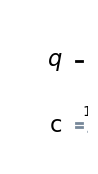

In [ ]:
# 3. Use the store instruction within a try...except block for safety
try:
  qc.store(target_clbit, uint_value_to_store)
  print('Success')

  display(qc.draw('mpl'))
except Exception as e:
  print('Failed')

In [ ]:
# Inspect the circuit data to confirm the instruction was added
if qc.data:
    print('Last instruction in circuit data:', qc.data[-1])
else:
    print('No instructions in the circuit.')

Last instruction in circuit data: CircuitInstruction(operation=Instruction(name='store', num_qubits=0, num_clbits=0, params=[Var(<Clbit register=(1, "c"), index=0>, Bool()), Cast(Value(1, Uint(8)), Bool(), implicit=True)]), qubits=(), clbits=())


In [ ]:
import qiskit
qiskit.__version__

'2.4.1'

#**Uncontrolled unitary gates**

standard gates that do not have controlled conditions (eg.X, H, Swap)


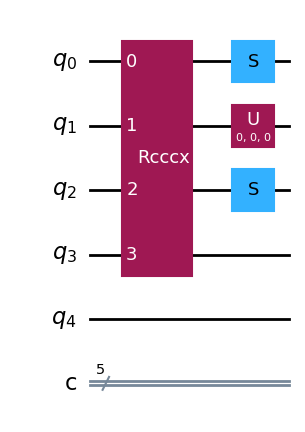

In [ ]:
qc = QuantumCircuit(5, 5)
qc.rcccx(0, 1, 2, 3)
qc.s([0, 2])
qc.u(0,0,0,1)
# qc.u(theta, phi, lam, qubit)
###      0     0    0    1
qc.draw('mpl')

##**Controlled Unitary Gates**

Gates that are activated based on the state of control qubits(eg. CX, CCX, CRZ)

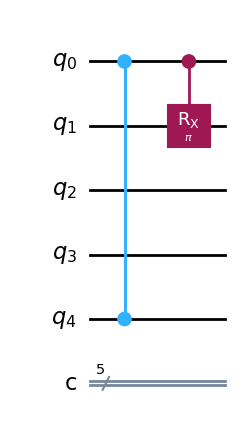

In [ ]:
import numpy as np
qc = QuantumCircuit(5, 5)
qc.cz(0, 4)
qc.crx(np.pi,0,1)
qc.draw('mpl')

## **Gates with Multiple Control**

Gates with multiple control lines, offering complex conditional logic.


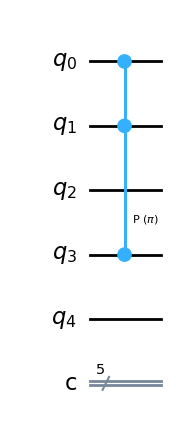

In [ ]:
qc = QuantumCircuit(5, 5)
qc.mcp(np.pi, [0,1], 3)
qc.draw('mpl')

## **Dynamic Circuits / Control Flow**

These circuits allow to change behaviour based on mid-circuit measurement results



In [ ]:
from qiskit.circuit import QuantumCircuit, BoxOp

body_0 = QuantumCircuit(4)
body_0.cz(0,1)
body_0.cz(2,3)

body_1 = QuantumCircuit(5)
body_1.cz(0,1)
body_1.cz(2,3)

qc = QuantumCircuit(9)
qc.box(body_0, [0, 1, 2, 3], [])
qc.box(body_1, [4, 5, 6, 7, 8], [])
qc.draw()

┌───────     ───────┐                      
q_0: ┤        ─■─        ├──────────────────────
     │         │         │                      
q_1: ┤        ─■─        ├──────────────────────
     │ Box-0       End-0 │                      
q_2: ┤        ─■─        ├──────────────────────
     │         │         │                      
q_3: ┤        ─■─        ├──────────────────────
     └───────     ───────┘┌───────     ───────┐ 
q_4: ─────────────────────┤        ─■─        ├─
                          │         │         │ 
q_5: ─────────────────────┤        ─■─        ├─
                          │                   │ 
q_6: ─────────────────────┤ Box-0  ─■─  End-0 ├─
                          │         │         │ 
q_7: ─────────────────────┤        ─■─        ├─
                          │                   │ 
q_8: ─────────────────────┤        ───        ├─
                          └───────     ───────┘

## Why use `box`?

| **Reason** | **Explanation** |
|---|---|
| Modularity | Group related gates into reusable blocks |
| Readability | Circuit diagram shows clean labeled boxes |
| Optimization | Compiler can treat a box as a single unit |
| Abstraction | Hide internal details of sub-circuits |

In short — it's like **functions in programming**, but for quantum circuits. Each box is a self-contained group of gates mapped onto specific qubits of the main circuit.

In [ ]:
qc = QuantumCircuit(9)

with qc.box(label="Box-A"):
  qc.cz(0, 1)
  qc.cz(2, 3)
with qc.box(label="Box-B"):
  qc.cz(4, 5)
  qc.cz(6, 7)
  qc.noop(8)

qc.draw()

┌───────     ───────┐                      
q_0: ┤        ─■─        ├──────────────────────
     │         │         │                      
q_1: ┤        ─■─        ├──────────────────────
     │ Box-0       End-0 │                      
q_2: ┤        ─■─        ├──────────────────────
     │         │         │                      
q_3: ┤        ─■─        ├──────────────────────
     └───────     ───────┘┌───────     ───────┐ 
q_4: ─────────────────────┤        ─■─        ├─
                          │         │         │ 
q_5: ─────────────────────┤        ─■─        ├─
                          │                   │ 
q_6: ─────────────────────┤ Box-0  ─■─  End-0 ├─
                          │         │         │ 
q_7: ─────────────────────┤        ─■─        ├─
                          │                   │ 
q_8: ─────────────────────┤        ───        ├─
                          └───────     ───────┘

## What `with` does here specifically

| **Without `with`** | **With `with`** |
|---|---|
| You manually build a separate `body` circuit | Gates are written directly inline |
| Pass body as argument: `qc.box(body, qubits, [])` | Qiskit automatically captures the gates |
| More verbose, error-prone | Cleaner, easier to read |

#**with in Quantum Circuits**
In normal Python, with manages resources (like opening a file). But here it's used differently — it collects gates into a block to tell Qiskit "these gates belong inside this control structure."

Without with, Qiskit would have no way to know which gates are part of the loop body and which aren't:

*In short — with is just Qiskit's way of saying "everything indented here belongs to this operation."*

In [ ]:
import warnings

qc = QuantumCircuit(2, 1)

with qc.for_loop(range(5)) as i:
   qc.x(0)
   qc.cx(0,1)
   qc.measure(0, 0)
   with qc.if_test((0, True)):
     qc.break_loop()

with warnings.catch_warnings():
    warnings.simplefilter('ignore')
    qc.draw()



/usr/local/lib/python3.12/dist-packages/qiskit/visualization/circuit/circuit_visualization.py:301: RuntimeWarning: Cregbundle set to False since an instruction needs to refer to individual classical wire
  if check_clbit_in_inst(block, cregbundle) is False:


┌─────────────────── ┌───┐     ┌─┐┌────── ┌─────────────┐ ───────┐ »
q_0: ┤                    ┤ X ├──■──┤M├┤       ┤1            ├        ├─»
     │ For-0 range(0, 5)  └───┘┌─┴─┐└╥┘│ If-1  │             │  End-1 │ »
q_1: ┤                    ─────┤ X ├─╫─┤       ┤0 Break_loop ├        ├─»
     └───────────────────      └───┘ ║ └──╥─── │             │ ───────┘ »
  c: ════════════════════════════════╩════■════╡0            ╞══════════»
                                               └─────────────┘          »
«      ───────┐ 
«q_0:         ├─
«       End-0 │ 
«q_1:         ├─
«      ───────┘ 
«  c: ══════════
«

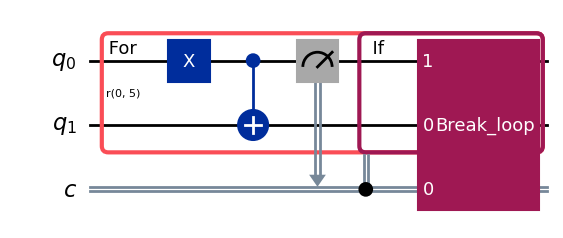

In [ ]:
qc.draw('mpl')

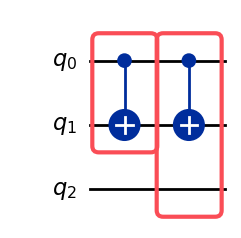

In [ ]:
qc = QuantumCircuit(3)

with qc.box():
  qc.cx(0,1)
with qc.box():
  qc.cx(0,1)
  qc.noop(2) # qubit 2 is idle but still is part of the loop
qc.draw('mpl')

## **if_else**


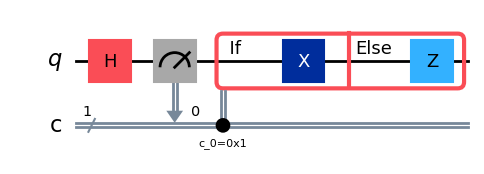

In [ ]:
from qiskit import QuantumCircuit
import warnings
warnings.filterwarnings('ignore', message='.*Cregbundle.*')
qc = QuantumCircuit(1,1)
qc.h(0)
qc.measure(0,0)

with qc.if_test((0,1)) as else_block:
  qc.x(0)
with else_block:
  qc.z(0)
qc.draw('mpl')


**Why if_test(0, 1) and not just if c[0] == 1?**

Because quantum circuits are descriptions of operations, not imperative code. You can't use a regular Python if — the circuit must encode the condition as a gate-level instruction that runs on the quantum hardware or simulator at runtime, after the actual measurement occurs.

##**While**

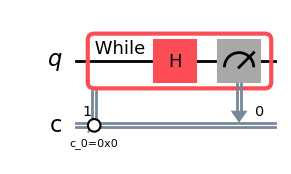

In [ ]:
qc = QuantumCircuit(1, 1)
with qc.while_loop((0, 0)):
  qc.h(0)
  qc.measure(0, 0)
qc.draw('mpl')

## **Switch**

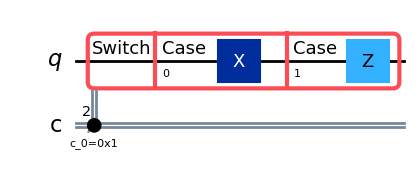

In [ ]:
qc = QuantumCircuit(1, 2)
with qc.switch(0) as case:
  with case(0):
    qc.x(0)
  with case(1):
    qc.z(0)
qc.draw('mpl')


##**Continue_loop**

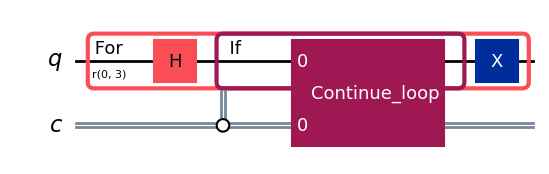

In [ ]:
qc = QuantumCircuit(1, 1)
with qc.for_loop(range(3)):
  qc.h(0)
  with qc.if_test((0, 0)):
    qc.continue_loop()
  qc.x(0)
qc.draw('mpl')

#**Converter**

Methods to package a circuit into a single `Instruction` or `Gate` object for reuse.

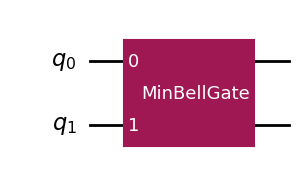

In [ ]:
qc_gate = QuantumCircuit(2)
qc_gate.h(0)
qc_gate.cx(0, 1)

# convert to gate
my_gate = qc_gate.to_gate()
my_gate.name = "MinBellGate"

# use it in a new circuit
main_qc = QuantumCircuit(2)
main_qc.append(my_gate, [0,1])
main_qc.draw('mpl')

## Helper Mutation Methods

Methods that modify the circuit in place, often to prepare it for execution.

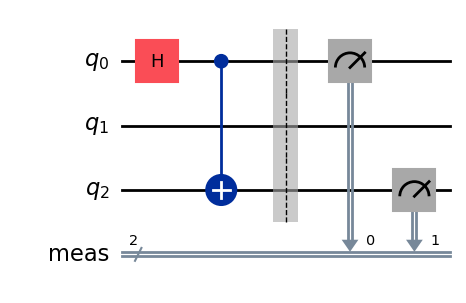

In [ ]:
qc3 = QuantumCircuit(3)

qc3.h(0)
qc3.cx(0,2)
qc3.measure_active()
qc3.draw('mpl')

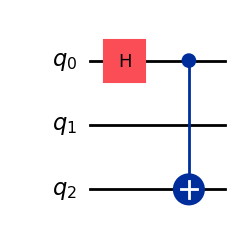

In [ ]:
qc3.remove_final_measurements()
qc3.draw('mpl')

### measure_all

Adds measurements to ALL qubits, extending the classical register if necessary.

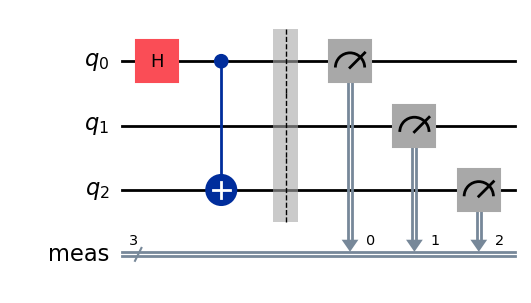

In [ ]:
qc3.measure_all()
qc3.draw('mpl')

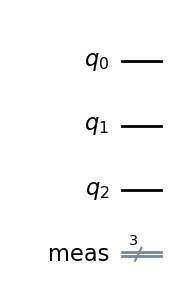

In [ ]:
qc3.clear()
qc3.draw('mpl')